Цель работы: изучение связи между признаками двумерного набора данных, визуализация данных.

Общее задание:
1. Загрузить датасет с помощью библиотеки pandas. Оценить его через info и describe. 
Выполнить предварительную обработку данных, если это необходимо.

2. Построить точечную диаграмму (матрицу диаграмм рассеяния) для всех признаков.
Выполнить анализ полученной диаграммы, отвечая на вопрос показывает ли она в
среднем определенную зависимость между переменными. Изучите параметры и
опишите взаимосвязи. Если параметров слишком много – может потребоваться
создать несколько графиков. Минимум один график (диаграмму рассеивания)
сделать по категориям (Например, зависимость зарплаты и возраста по каждой
должности. На таком графике различные должности должны быть показаны разными
цветами).

3. Постройте гистограммы для каждого числового признака, подберите оптимальное
количество bins, сделайте выводы по полученными гистограммам.

4. Исследовать взаимосвязь между переменными с помощью оценки коэффициента
корреляции и ковариации. Построить heatmap (тепловую карту корреляции).
Выполнить интерпретацию результатов корреляции и ковариации, отвечая на вопросы 
о наличии (отсутствии) линейной взаимосвязи между переменными. Понимать, что
такое корреляция и ковариация.

5. Постройте графики по заданию в варианте. Выполните интерпретацию, что вы видите
на этих графиках.

6. Выполните минимум один любой график типа hexagonal binning plot. Сделайте
выводы.

7. Выполните минимум один график типа boxplot для любого столбца. Сделайте выводы.

8.  Добавьте категорию по любому числовому столбцу (например, уровень зарплаты -
высокий, низкий, средний). Сделайте boxplot по этому числовому столбцу по каждой
новой категории (на boxplot будет box-ы для средней, низкой и высокой зарплаты).

9. Выполните ещё минимум 2 графика boxplot по другим категориям (например,
зарплата по полу, зарплата по должности и т.п. - в результате несколько box-ов для
каждой категории на ном графике). Используйте для построения графиков разные
библиотеки (минимум 2). Сделайте вывод.

10. Сделайте общие выводы по работе. В том числе с качественной интерпретацией.

Индвидидуальное задание - вариант 7:

Набор данных salary2.csv

Содержит информацию о зарплатах.
1. Год выплаты заработной платы (целое число)
2. Тип работы (PT - Part-time, FT - Full-time, FL - Freelance)
3. Должность
4. Зарплата за год (целое число)
5. Зарплата в долларах (целое число)
6. Страна проживания
7. Страна главного офиса
8. Среднее кол-во людей в компании (S - менее 50 сотрудников (малая), M от 50 до 250 сотрудников (средняя), L - более 250 сотрудников (крупная))
9. Общий опыт работы
10. Опыт на последней работе

Задание 1: Использовать seaborn. По группировке - work_year и количество
компаний по различному типу занятости (employment_type) построить диаграмму
следующего вида:

<img src="task1.png" alt="" height="300"/>

Задание 2: Использовать pandas и plot. По сводной таблице (pivot_table) -
отобразить среднюю зарплату в usd по локациям (company_location). Сделать
линию зелёной, шириной 4 и отобразить маркеры в виде *.

<img src="task2.png" alt="" height="300"/>

Задание 3: Использовать matplotlib. Построить круговую диаграмму, которая
отображает процент количества записей по каждому году.

<img src="task3.png" alt="" height="300"/>


# 1. Предварительный анализ данных и обработка

## 1.1. Чтение набора данных

В начале работы были подключены необходимые библиотеки для анализа и визуализации данных (pandas, seaborn, matplotlib). Затем был считан CSV-файл salary2.csv в датафрейм pandas для дальнейшей обработки и анализа

In [530]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# считывание файл в датафрейм.
# используется sep для определения символа разделителя в датасете,
# нужно чтобы датасет загрузился в правильном формате.
df = pd.read_csv('salary2.csv', sep=';')

## 1.2 Первичная оценка данных

Для ознакомления с набором данных, были использованы методы head, info и describe.

In [531]:
print(df.head())
print()
print(df.info())
print()
print(df.describe())

   work_year employment_type             job_title      salary  salary_in_usd  \
0     2020.0              FT        Data SCIENTIST     70000.0        79833.0   
1     2020.0              FT  Product Data Analyst     20000.0        20000.0   
2     2020.0              FT          Data Analyst     72000.0        72000.0   
3     2020.0              FT        Data Scientist  11000000.0        35735.0   
4     2020.0              FT        Data Scientist     45000.0        51321.0   

  employee_residence company_location company_size  exp_all  exp  
0                 DE               DE            L        9    4  
1                 HN               HN            S        2    2  
2                 US               US            L       13    3  
3                 HU               HU            L       60    6  
4                 FR               FR            S        8    4  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 10 columns):
 #   

По выводу программы можно сделать следующие замечания:
1. Тип колонки work_year вещественный, хотя должен быть целочисленным по заданию.
2. Стоит проверить наличие аномалий в колонке employment_type, там могу содержаться неявные дубликаты.
3. Аналогично стоит проверить и колонку job_title, даже в выводе head видно дубликат (Data SCIENTIST - Data Scientist)
4. Колонки salary и salary_in_usd должны быть целочисленными.
5. В колонке salary присутствуют 3 пропуска данных. 
6. Стоит проверить налаичие аномалий в колонке employee_residence, company_location и company_size.
7. Стоит проверить аномалии в связке колонок exp_all и exp. Например слишком большие или маленькие значения, а также не соотвествие между совокупным и последним опытом.

## 1.3 Обработка данных

Сначала из данных были устранены пропуски. Так как пропусков мало, всего 3, то было принято решение удалить такие строчки, а не заменять их значениями.

In [532]:
# удаление строк с пропущенными значениями при помощи dropna
df = df.dropna(subset=['salary'])

# восстановление индексации при помощи reset_index.
# дополнительный столбец index не создается при помощи аргумента drop=True.
df = df.reset_index(drop=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           398 non-null    float64
 1   employment_type     398 non-null    object 
 2   job_title           398 non-null    object 
 3   salary              398 non-null    float64
 4   salary_in_usd       398 non-null    float64
 5   employee_residence  398 non-null    object 
 6   company_location    398 non-null    object 
 7   company_size        398 non-null    object 
 8   exp_all             398 non-null    int64  
 9   exp                 398 non-null    int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 31.2+ KB
None


Затем были исправлены типы данных, при помощи метода astype.

In [533]:
df['work_year'] = df['work_year'].astype('int64')
df['salary'] = df['salary'].astype('int64')
df['salary_in_usd'] = df['salary_in_usd'].astype('int64')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           398 non-null    int64 
 1   employment_type     398 non-null    object
 2   job_title           398 non-null    object
 3   salary              398 non-null    int64 
 4   salary_in_usd       398 non-null    int64 
 5   employee_residence  398 non-null    object
 6   company_location    398 non-null    object
 7   company_size        398 non-null    object
 8   exp_all             398 non-null    int64 
 9   exp                 398 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 31.2+ KB
None


После были устранены явные дубликаты, а для устранения неявных дубликатов были выведены уникальные значения в рассматриваемых столбцах.

In [534]:
print('количество явных дубликатов')
print(df.duplicated().sum())
print()

# удаление дубликатов (если они есть)
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print('уникальные значения в столбце employment_type')
print(df['employment_type'].unique())
print()

print('уникальные значения в столбце job_title')
print(df['job_title'].unique())
print()

print('уникальные значения в столбце employee_residence')
print(df['employee_residence'].unique())
print()

print('уникальные значения в столбце company_location')
print(df['company_location'].unique())
print()

print('уникальные значения в столбце company_size')
print(df['company_size'].unique())
print()

количество явных дубликатов
0

уникальные значения в столбце employment_type
['FT' 'PT' 'FL']

уникальные значения в столбце job_title
['Data SCIENTIST' 'Product Data Analyst' 'Data Analyst' 'Data Scientist'
 'Data Engineer' 'Machine Learning Manager' 'Data Analytics Engineer'
 'Data Science Engineer' 'Machine Learning Developer'
 'Data Analytics Manager' 'Head of Data Science'
 'Head of Machine Learning' 'NLP Engineer' 'Data Analytics Lead'
 'DataScientist' 'Data AnalyticsManager']

уникальные значения в столбце employee_residence
['DE' 'HN' 'US' 'HU' 'FR' 'IN' 'PK' 'JP' 'GR' 'MX' 'CA' 'AT' 'NG' 'PH'
 'GB' 'ES' 'IT' 'PL' 'BG' 'NL' 'IQ' 'UA' 'SG' 'RU' 'MT' 'CL' 'RO' 'IR'
 'VN' 'BR' 'HK' 'TR' 'RS' 'AR' 'DZ' 'AU' 'CH']

уникальные значения в столбце company_location
['DE' 'HN' 'US' 'HU' 'FR' 'IN' 'PK' 'JP' 'GR' 'MX' 'CA' 'AT' 'NG' 'GB'
 'ES' 'IT' 'LU' 'PL' 'NL' 'IQ' 'UA' 'IL' 'RU' 'MT' 'CL' 'IR' 'BR' 'VN'
 'TR' 'DZ' 'MY' 'AU' 'CH']

уникальные значения в столбце company_size
['L' 'S' 'M'

В выводе программы неявные дубликаты были обнаружены в столбце job_title: Data SCIENTIST - Data Scientist - DataScientist, Data AnalyticsManager - Data Analytics Manager. Дополинтельно неявный дубликаты присутствуют и в столбце company_size - Large и L.

Дубликаты были устранены при помощи метода replace.

In [535]:
# regex=True используется для удобного перечисления значений для замены при помощи прямого слэша '|'
df['job_title'] = df['job_title'].replace('Data SCIENTIST|DataScientist', 'Data Scientist', regex=True)
df['job_title'] = df['job_title'].replace('Data AnalyticsManager', 'Data Analytics Manager')
df['company_size'] = df['company_size'].replace('Large', 'L')

print('уникальные значения в столбце job_title после обработки')
print(df['job_title'].unique())
print()

print('уникальные значения в столбце company_size после обработки')
print(df['company_size'].unique())

уникальные значения в столбце job_title после обработки
['Data Scientist' 'Product Data Analyst' 'Data Analyst' 'Data Engineer'
 'Machine Learning Manager' 'Data Analytics Engineer'
 'Data Science Engineer' 'Machine Learning Developer'
 'Data Analytics Manager' 'Head of Data Science'
 'Head of Machine Learning' 'NLP Engineer' 'Data Analytics Lead']

уникальные значения в столбце company_size после обработки
['L' 'S' 'M']


Последней частью обработки будет исправления аномалий в колонках exp и exp_all. Сначала будут произведены расчеты, а затем выбрана тактика исправлений (удаление/замена).

In [536]:
print('противоречащие связки exp > exp_all:')
print(df[df['exp'] > df['exp_all']][['exp', 'exp_all']])
print()

print('количество отрицательных значений exp:')
print(df[df['exp'] < 0].shape[0])
print()

print('количество отрицательных значений exp_all:')
print(df[df['exp_all'] < 0].shape[0])
print()

print('максимальные exp с их количеством')
# получаем 5 максимальных exp, убираем дубликаты, приводим к python списку.
# далее фильтруем датафрейм по максимальным exp, группируем по ним же, считаем количество строк по каждому максимальному exp.
top5exp = df['exp'].nlargest(5).drop_duplicates().to_list()
top5exp_count = df[df['exp'].isin(top5exp)].groupby('exp').size().sort_values().reset_index(name='count')
print(top5exp_count)
print()

print('максимальные exp_all:')
top5exp_all = df['exp_all'].nlargest(5).drop_duplicates().to_list()
top5exp_all_count = df[df['exp_all'].isin(top5exp_all)].groupby('exp_all').size().sort_values().reset_index(name='count')
print(top5exp_all_count)
print()

противоречащие связки exp > exp_all:
     exp  exp_all
8      4        1
11     8        4
17     2        1
27     7        5
41     6        3
61     6        4
65     7        0
68     9        7
78     7        2
83     7        4
91     6        3
92     1        0
101    7        3
116    8        0
134    4        3
139   10        7
251    8        4
267    6        3
272    8        6
320    7        5
324    3        2

количество отрицательных значений exp:
1

количество отрицательных значений exp_all:
0

максимальные exp с их количеством
   exp  count
0   10      1
1    9      6

максимальные exp_all:
   exp_all  count
0       56      1
1       58      1
2       60      1
3       72      1
4       81      1



In [537]:
# находим все строчки где exp > exp_all.
# с помощью loc заменяем exp_all в этих строчках на exp.
exp_less_all = df['exp'] > df['exp_all']
df.loc[exp_less_all, 'exp_all'] = df['exp']

# удаляем отрицательные значения exp
df = df[df['exp'] >= 0]
df = df.reset_index(drop=True)

print('количество противоречащих связок exp > exp_all:')
print(df[df['exp'] > df['exp_all']][['exp', 'exp_all']].shape[0])
print()

print('количество отрицательных значений exp:')
print(df[df['exp'] < 0].shape[0])
print()

print('количество записей:')
print(df.shape[0])

количество противоречащих связок exp > exp_all:
0

количество отрицательных значений exp:
0

количество записей:
397


В исходных данных было не так много противоречащих связок exp и exp_all, поэтому было принято решение заменить exp_all на exp в случае когда exp > exp_all, хотя данные можно было и удалить.

Максимальные значение exp находятся в пределах нормы, а вот exp_all имеет довольное большие макисмальные значения, причем каждое из которых встречается по 1 разу - 81, 72, 60, 58, 56. Было принято решение не удалять такие данные, допустим что человек может иметь стаж около 80 лет за всюсвою жизнь.

Отрицательные значения exp были удалены.

Итого после обработки осталось 397 значений, то есть удалено всего 4 от исходных 401.

# 2. Точечная диаграмма (матрица диаграмм рассеяния)

После предобработки данных была построена матрица диаграмм рассеяния для числовых признаков, затем была добавлена раскраска по категориям и была создана фокусная диаграмма "зарплата - общий опыт работы" по должностям. Это позволило увидеть общие связи, выбросы и различия между группами.

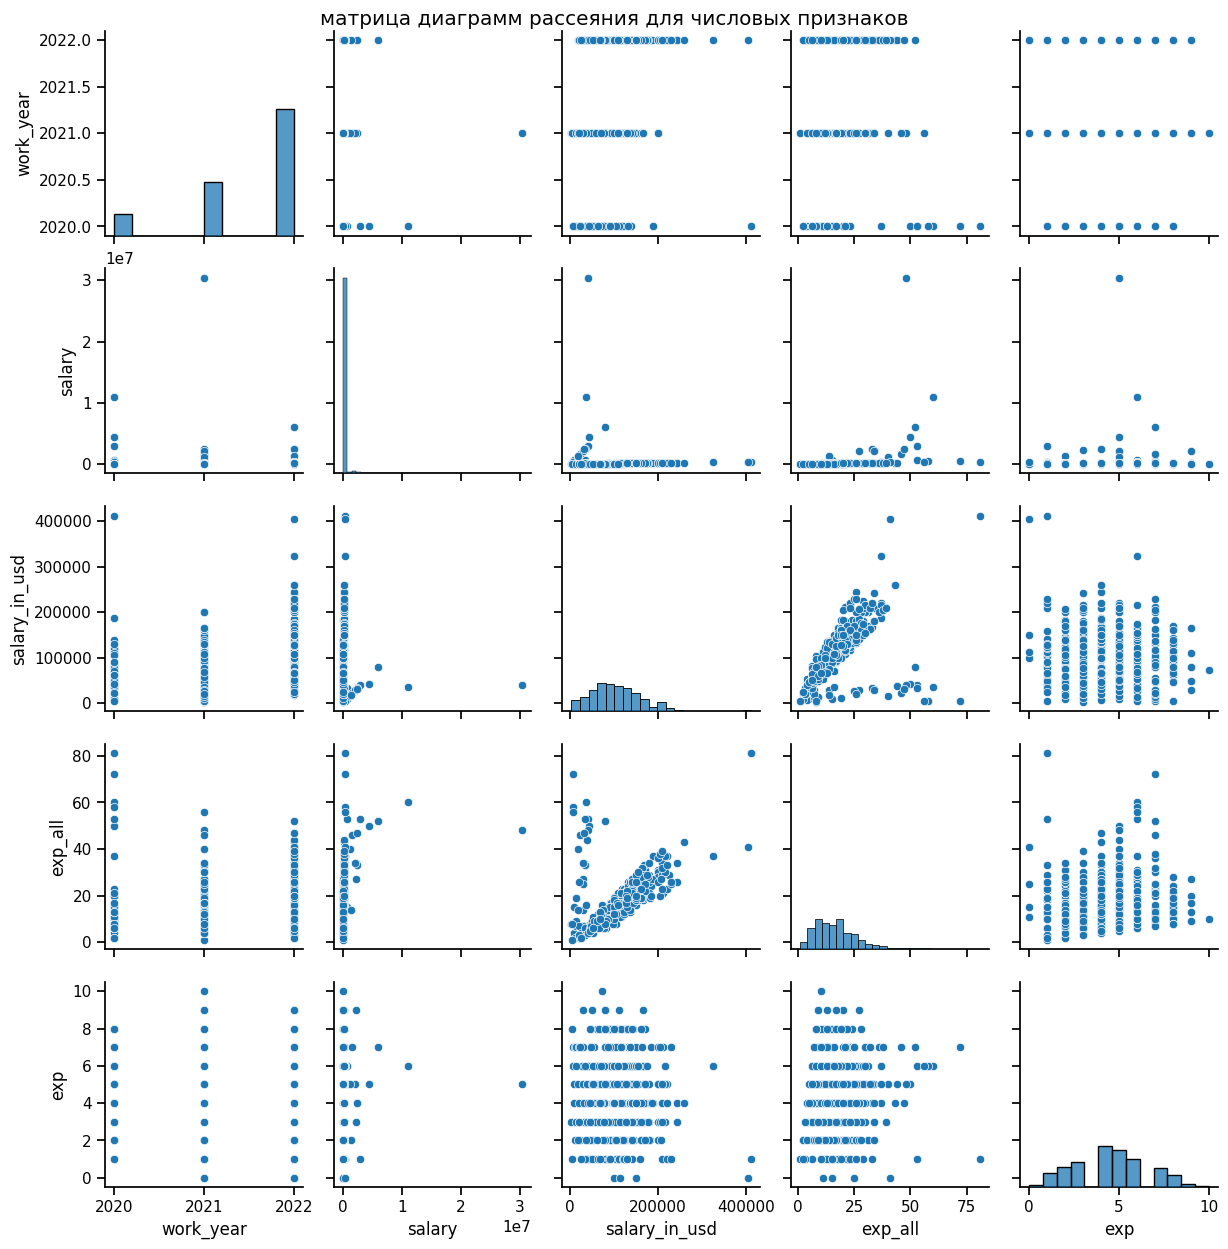

In [538]:
# выделение числовых столбцов

# select_dtypes(include='number') - вернет список столбцов с числовыми типами,
# это будет использоваться, чтобы в матрицу диаграмм попадали только числовые признаки
num_cols = df.select_dtypes(include='number').columns.tolist()

# матрица диаграмм рассеяния для всех числовых признаков.
# pairplot - построит попарные scatter-графики для всех пар столбцов,
# по диагонали по умолчанию будут показаны распределения каждого признака
pp = sb.pairplot(df[num_cols])
plt.suptitle('матрица диаграмм рассеяния для числовых признаков', y=1)
plt.show()

# также для построения матрицы диаграмм можно будет использовать pandas вместо seaborn:
# pd.plotting.scatter_matrix(df[num_cols], figsize=(9, 9))
# plt.suptitle('матрица диаграмм рассеяния (pandas)')
# plt.show()

По созданному графику были подведены следующие итоги:
- salary и salary_in_usd смещались вверх‑вправо, что указывало на совместный рост показателей; из‑за разных валют в salary наблюдались большие вертикальные разбросы и выбросы.
- exp_all и exp выстраивались в узкую восходящую полосу, что отражало сильную линейную зависимость между общим и последним опытом.
- work_year образовывал три вертикальные группы (2020, 2021, 2022); заметных трендов с зарплатой и опытом выявлено не было.
- salary_in_usd с ростом exp_all/exp имел повышающуюся верхнюю границу значений; при этом разброс оставался большим, что указывало на влияние локации, размера компании и должности.

Далее была проверена картина связей по типу занятости через раскраску точек по employment_type (FT/PT/FL).

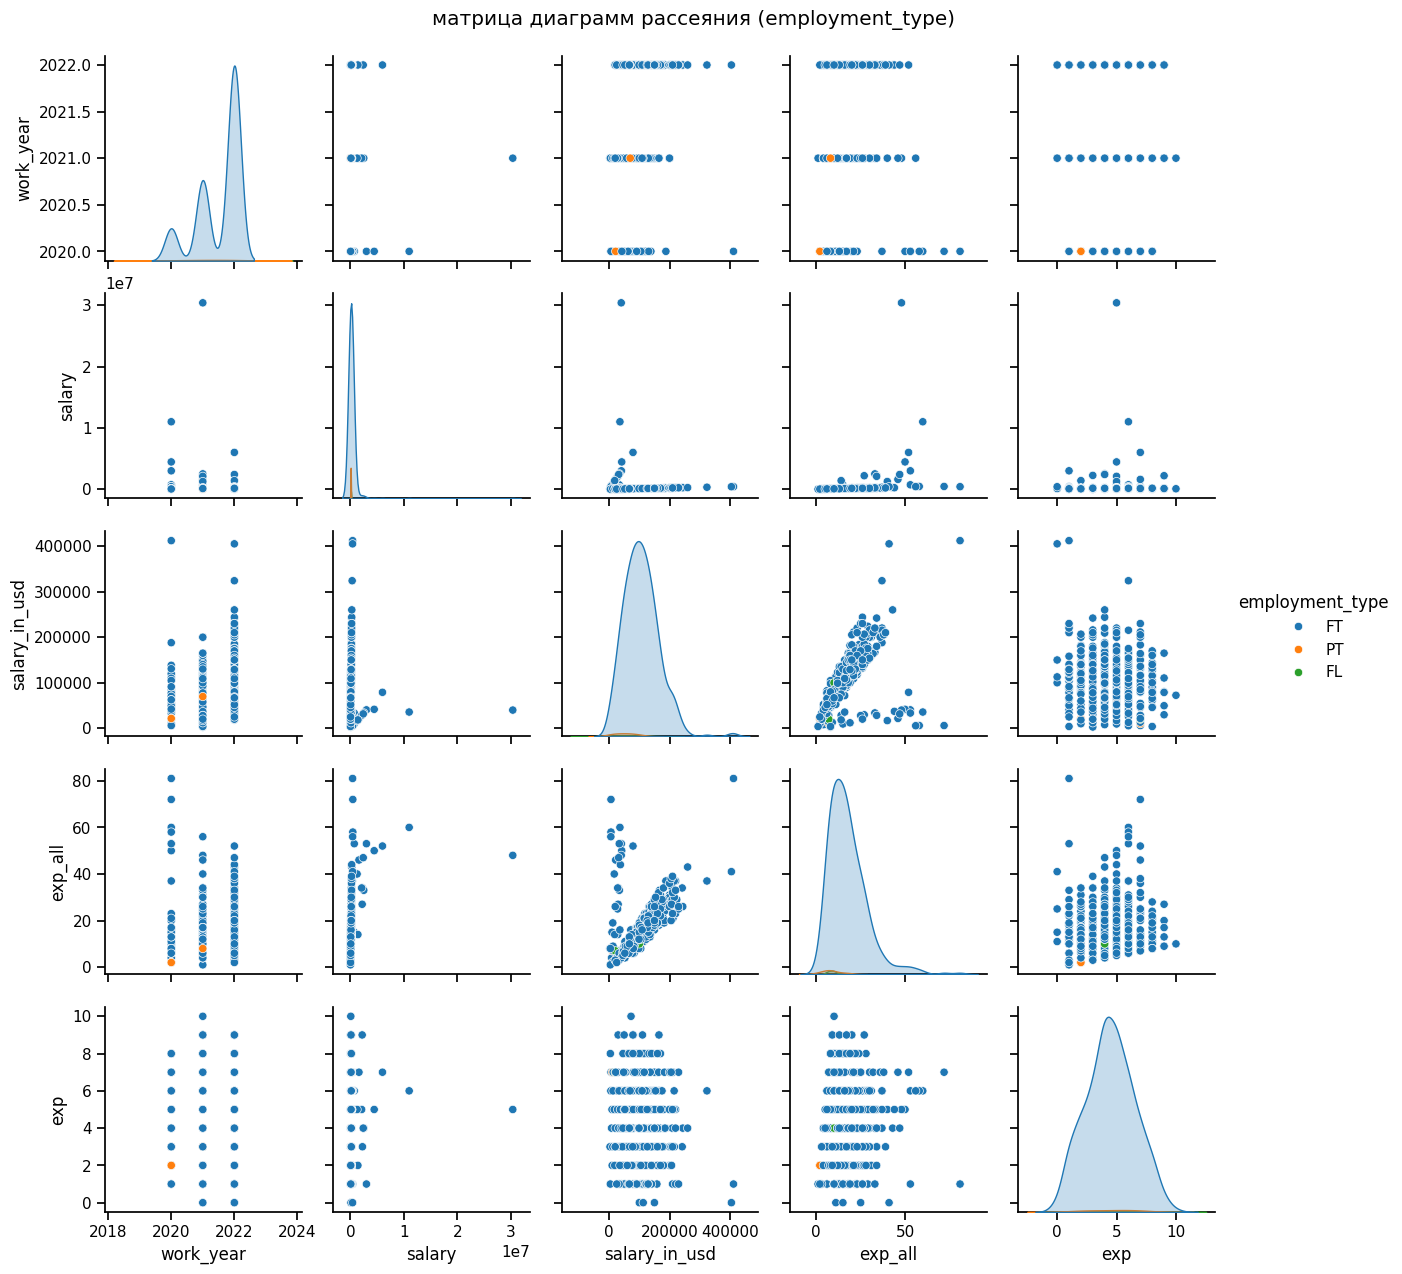

In [539]:
# матрица диаграмм рассеяния с окраской по типу занятости.
# параметр hue='employment_type' будет раскрашивать точки по категориям FT/PT/FL
pp_hue = sb.pairplot(df[num_cols + ['employment_type']], hue='employment_type')
plt.suptitle('матрица диаграмм рассеяния (employment_type)', y=1.02)
plt.show()

По созданному графику были подведены следующие итоги:
- FT преобладал и чаще встречался в верхней части по salary_in_usd.
- PT и FL концентрировались в более низких диапазонах зарплат и имели более компактные облака точек.
- различия проявлялись в уровнях и разбросе значений; форма зависимостей оставалась схожей.

Затем была построена фокусная диаграмма "зарплата в usd - общий опыт" по топ‑3 должностям, чтобы сравнить уровни по ролям.

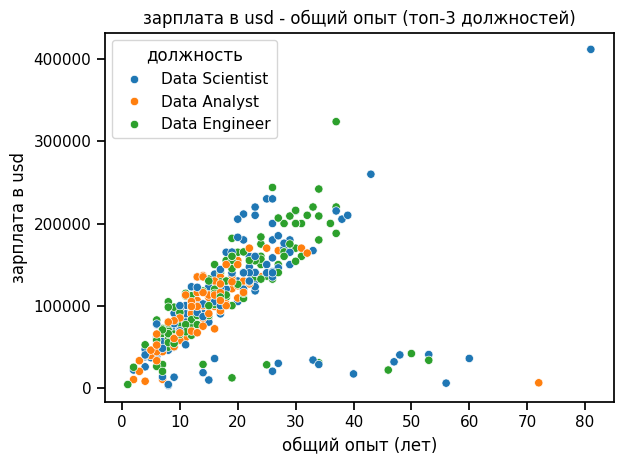

In [540]:
# выбор топ-3 должностей по частоте
# value_counts().nlargest(3) - вернет 3 самых частых должностей
top_titles = df['job_title'].value_counts().nlargest(3).index
df_top = df[df['job_title'].isin(top_titles)].copy()

# диаграмма рассеяния "зарплата - общий опыт" по должностям.
# hue='job_title' будет раскрашивать точки по выбранным должностям
sb.scatterplot(data=df_top, x='exp_all', y='salary_in_usd', hue='job_title')
plt.title('зарплата в usd - общий опыт (топ-3 должностей)')
plt.xlabel('общий опыт (лет)')
plt.ylabel('зарплата в usd')
plt.legend(title='должность')
plt.tight_layout()
plt.show()

По созданному графику были подведены следующие итоги (топ-3 должностей):
- При опыте 0-10 лет распределения трех ролей пересекались; выраженных различий по уровням зарплаты не наблюдалось.
- Начиная примерно с 10-15 лет опыта наблюдалось расхождение уровней: Data Engineer располагался выше, Data Scientist — чуть ниже, Data Analyst — стабильно ниже остальных.
- Тенденция роста зарплаты с опытом сохранялась до ~30 лет; далее рост замедлялся и увеличивалась вариативность значений.
- Отмечались редкие высокие значения (>300k usd) преимущественно у Data Engineer и Data Scientist.
- Наблюдались единичные низкие значения при большом опыте (40-80 лет), что выглядело как выбросы.

# 3. Гистограммы числовых признаков

После матрицы диаграмм рассеяния были построены гистограммы для всех числовых столбцов. корзины были подобраны аналитически.
Затем все гистограммы были сведены в один рисунок с сеткой подграфиков, чтобы компактно показать распределения признаков.

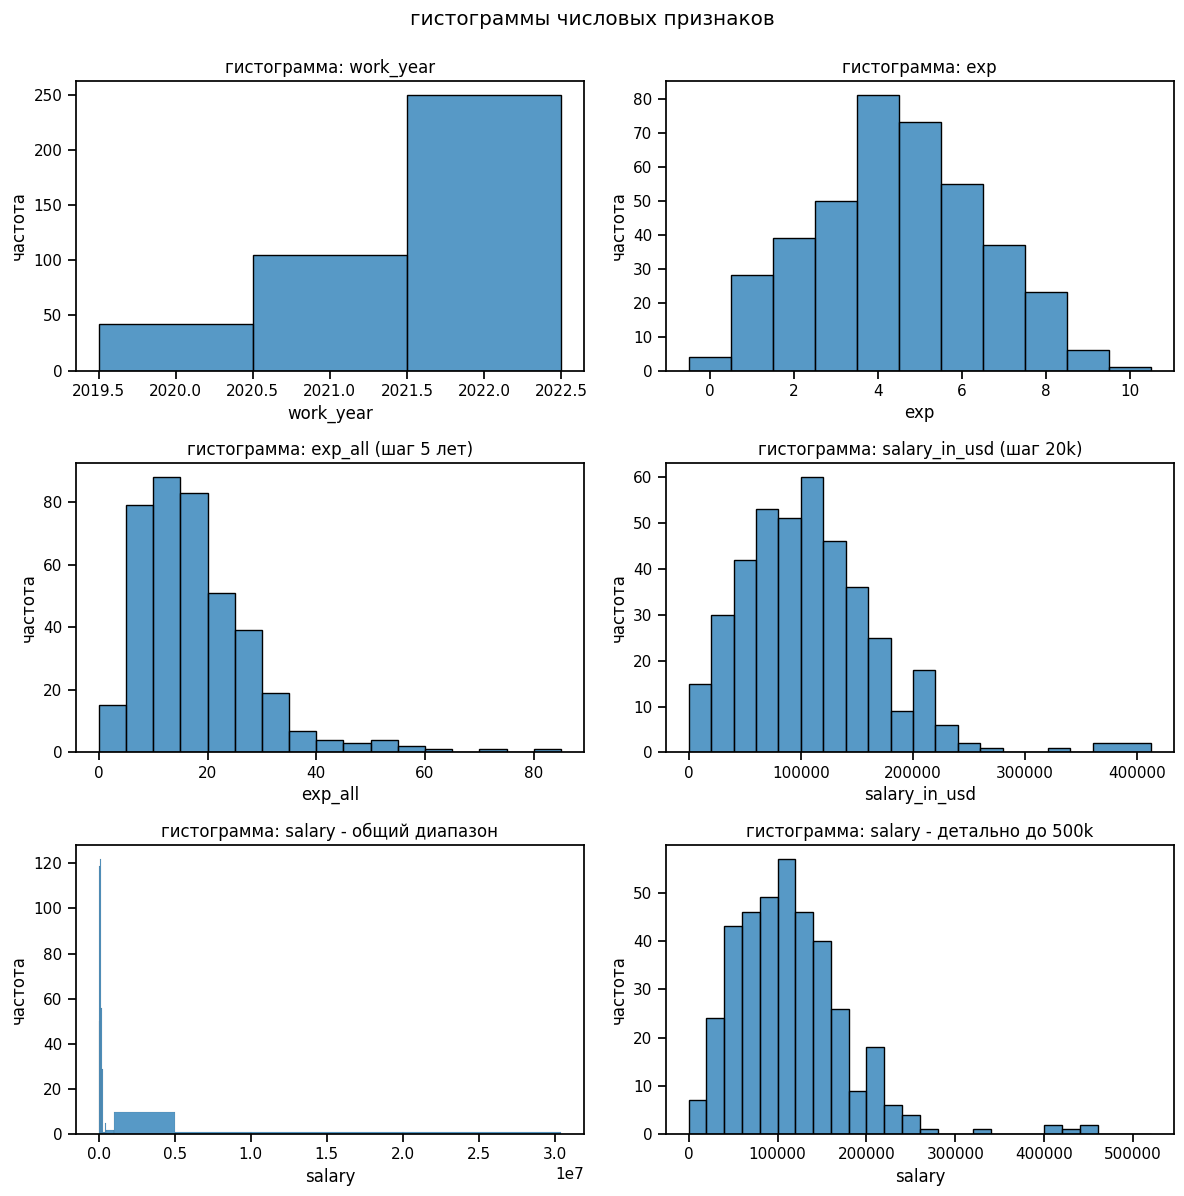

In [541]:
# подготовка границ корзин

# exp_all: будет применяться шаг 5 лет
# np.arange(a, b, step) - создаст последовательность границ с шагом step, правая граница b не будет включена
exp_all_bins = np.arange(0, 86, 5)  # 0-5, 5-10, ..., 80-85

# salary_in_usd: будет задаваться шаг 20k + хвост до максимума
usd_max = int(df['salary_in_usd'].max())
usd_edges = list(range(0, 360_001, 20_000)) + [usd_max + 1]  # 0..360k и финальная корзина до max

# salary: будет строиться общий вид по всему диапазону и детальный вид до 500k
sal_max = int(df['salary'].max())
sal_edges_full = [0, 50_000, 100_000, 150_000, 200_000, 300_000, 400_000, 500_000,
                  1_000_000, 5_000_000, 10_000_000, 20_000_000, sal_max + 1]
sal_edges_zoom = list(range(0, 520_001, 20_000))  # 0..520k с шагом 20k

# единый рисунок со всеми гистограммами
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()

# work_year - дискретные годы: будет использоваться дискретная отрисовка по уникальным значениям
sb.histplot(data=df, x='work_year', discrete=True, ax=axes[0])
axes[0].set_title('гистограмма: work_year')
axes[0].set_xlabel('work_year')
axes[0].set_ylabel('частота')

# exp - целые 0..10: будет использоваться дискретная отрисовка по значениям
sb.histplot(data=df, x='exp', discrete=True, ax=axes[1])
axes[1].set_title('гистограмма: exp')
axes[1].set_xlabel('exp')
axes[1].set_ylabel('частота')

# exp_all - стаж 1..81: будет применяться шаг 5 лет
sb.histplot(data=df, x='exp_all', bins=exp_all_bins, ax=axes[2])
axes[2].set_title('гистограмма: exp_all (шаг 5 лет)')
axes[2].set_xlabel('exp_all')
axes[2].set_ylabel('частота')

# salary_in_usd - основной диапазон до ~300k: будет задаваться шаг 20k + хвост до максимума
sb.histplot(data=df, x='salary_in_usd', bins=usd_edges, ax=axes[3])
axes[3].set_title('гистограмма: salary_in_usd (шаг 20k)')
axes[3].set_xlabel('salary_in_usd')
axes[3].set_ylabel('частота')

# salary - общий диапазон: будет использоваться крупная сетка корзин
sb.histplot(data=df, x='salary', bins=sal_edges_full, ax=axes[4])
axes[4].set_title('гистограмма: salary - общий диапазон')
axes[4].set_xlabel('salary')
axes[4].set_ylabel('частота')

# salary - детально до 500k: будет использоваться шаг 20k для плотной зоны
sb.histplot(data=df[df['salary'] <= 520_000], x='salary', bins=sal_edges_zoom, ax=axes[5])
axes[5].set_title('гистограмма: salary - детально до 500k')
axes[5].set_xlabel('salary')
axes[5].set_ylabel('частота')

fig.suptitle('гистограммы числовых признаков', y=0.995)
plt.tight_layout()
plt.show()

Итоги по гистограммам:
- work_year - распределение было дискретным по трем годам; основной объем записей приходился на 2022 год, далее 2021, 2020 был представлен значительно меньше.
- exp - распределение было с пиком в 4-5 лет; значения 0-1 и 9-10 встречались редко, что указывало на концентрацию опыта на последнем месте в зоне 3-6 лет.
- exp_all - основная масса наблюдений располагалась в диапазоне 10-25 лет; правый хвост до 80+ лет был длинным и разреженным, что характерно для единичных наблюдений с очень большим общим стажем.
- salary_in_usd - распределение было правосторонним с выраженной модой в диапазоне 80k-120k и медианой около 100k; значения выше 250k встречались редко и формировали длинный хвост.
- salary - общий график показал сильную правую асимметрию и наличие экстремально больших значений (миллионы), из-за чего основная масса данных «сжималась» у нулевой области; детальный график до 500k подтвердил концентрацию зарплат в диапазоне примерно 60k-160k и редкость значений выше 200k-300k.

общий вывод - числовые признаки имели ожидаемую правую асимметрию по зарплатам, дискретность по годам и последнему опыту, а также длинный правый хвост по общему стажу и по зарплатам (особенно в локальных валютах). для аналитики корректнее было использовать salary_in_usd, так как распределение salary в локальных валютах искажалось валютными масштабами и выбросами.

# 4. Корреляция и ковариация. Тепловая карта

Для оценки линейных связей между числовыми признаками были рассчитаны матрицы корреляции и ковариации и была построена тепловая карта корреляций.

Определение метрик:
- Корреляция - статистическая мера зависимости между двумя переменными. может быть положительной, отрицательной или отсутствовать. коэффициент Пирсона принимает значения от -1 до 1, где 1 - положительная линейная связь, -1 - отрицательная, 0 - отсутствие линейной связи. наличие корреляции не доказывало причинно-следственную связь.
- Ковариация - мера совместного изменения двух переменных. знак совпадал со знаком корреляции; величина зависела от масштаба признаков, поэтому сравнивать силу связи между разными парами по ковариации было некорректно.

матрица корреляций (Пирсон):
               work_year  salary  salary_in_usd  exp_all    exp
work_year          1.000  -0.096          0.333    0.026 -0.010
salary            -0.096   1.000         -0.092    0.321  0.034
salary_in_usd      0.333  -0.092          1.000    0.500 -0.091
exp_all            0.026   0.321          0.500    1.000  0.028
exp               -0.010   0.034         -0.091    0.028  1.000

матрица ковариаций:
               work_year        salary  salary_in_usd    exp_all       exp
work_year            0.5 -1.094178e+05   1.310420e+04        0.2      -0.0
salary         -109417.8  2.819553e+12  -8.987570e+09  5897892.1  114082.3
salary_in_usd    13104.2 -8.987570e+09   3.356535e+09   317084.9  -10668.2
exp_all              0.2  5.897892e+06   3.170849e+05      120.0       0.6
exp                 -0.0  1.140823e+05  -1.066820e+04        0.6       4.1


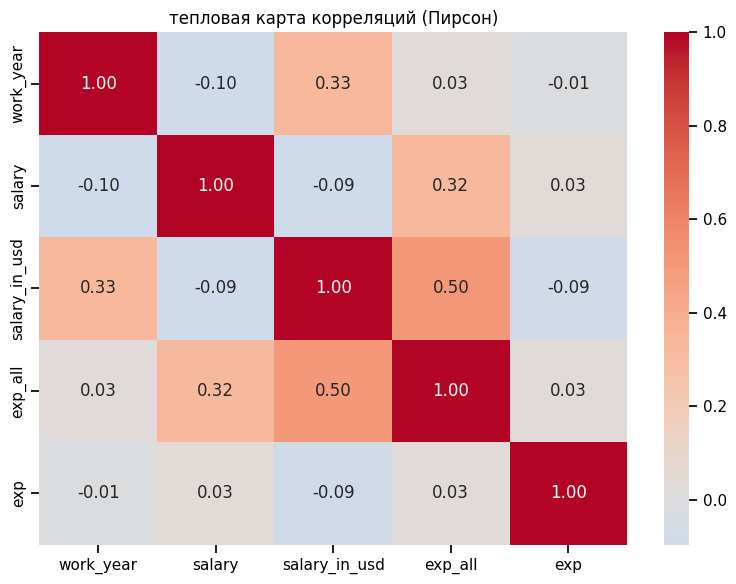

In [542]:
# матрицы корреляций и ковариаций

# будет вычисляться корреляция Пирсона для числовых столбцов
corr = df[num_cols].corr(method="pearson")
print("матрица корреляций (Пирсон):")
print(corr.round(3))

# будет вычисляться ковариация для числовых столбцов
cov = df[num_cols].cov()
print("\nматрица ковариаций:")
print(cov.round(1))

# тепловая карта корреляций
plt.figure(figsize=(8, 6))
# annot=True - будет наноситься численное значение в каждую ячейку
# fmt=".2f" - будет задаваться формат чисел с двумя знаками после запятой
# cmap="coolwarm" - применение цветовой шкалы.
# center=0 - будет центрироваться цветовая шкала на нуле, чтобы 0 был нейтральным цветом
sb.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("тепловая карта корреляций (Пирсон)")
plt.tight_layout()
plt.show()

# из методички дополинитный вариант через corrwith:
# df.corr()         # матрица корреляций
# df.cov()          # матрица ковариаций
# df.corrwith(df["salary_in_usd"], numeric_only=True)  # корреляция каждого признака с целевым

Интерпретация результатов:
- salary_in_usd и exp_all: была зафиксирована умеренная положительная связь r=0.50. в среднем зарплата в usd увеличивалась с ростом общего стажа.
- work_year и salary_in_usd: наблюдалась слабая положительная связь r=0.33. за 2020-2022 легкий рост зарплат был заметен, но диапазон лет был узким.
- salary и exp_all: наблюдалась слабая-умеренная положительная связь r=0.32. влияние общего стажа на salary в локальных валютах прослеживалось, но слабее из-за разнородности валют и масштабов.
- salary и salary_in_usd: наблюдалась слабая отрицательная связь r=-0.09, что соответствовало искажениям из-за разных исходных валют и наличия выбросов в salary.
- exp и все остальные: связи были близки к нулю (с exp_all r=0.03, с salary_in_usd r=-0.09, с work_year r=-0.01). последний опыт 0-10 лет распределялся почти независимо от общего стажа и года в рамках данных.

Замечания по ковариации:
- Знаки ковариации совпадали со знаками корреляции (например, cov(salary_in_usd, exp_all) > 0, cov(salary_in_usd, exp) < 0).
- Величины ковариаций с участием salary были большими из-за масштаба (единицы - произведение валютных единиц и лет). для сравнения силы связей использовалась корреляция.

Общий вывод:
- Линейная взаимосвязь была наиболее выраженной между salary_in_usd и exp_all (умеренная).
- Связи с work_year были слабыми из-за короткого периода 2020-2022.
- exp (последний опыт) почти не коррелировал с другими числовыми признаками.
- salary_in_usd являлся предпочтительной метрикой оплаты для анализа связей из-за сопоставимого масштаба и меньшего влияния валютных искажений, чем salary.

# 5. Выполнение индивидуальных заданий

В разделе были выполнены графики по варианту, после чего была дана краткая интерпретация наблюдений.

## 5.1. Задание 1 (seaborn)

По группировке work_year и количеству компаний по различному типу занятости (employment_type) была построена столбчатая диаграмма. по оси x располагались типы занятости (FT, PT, FL), цветом были показаны годы.

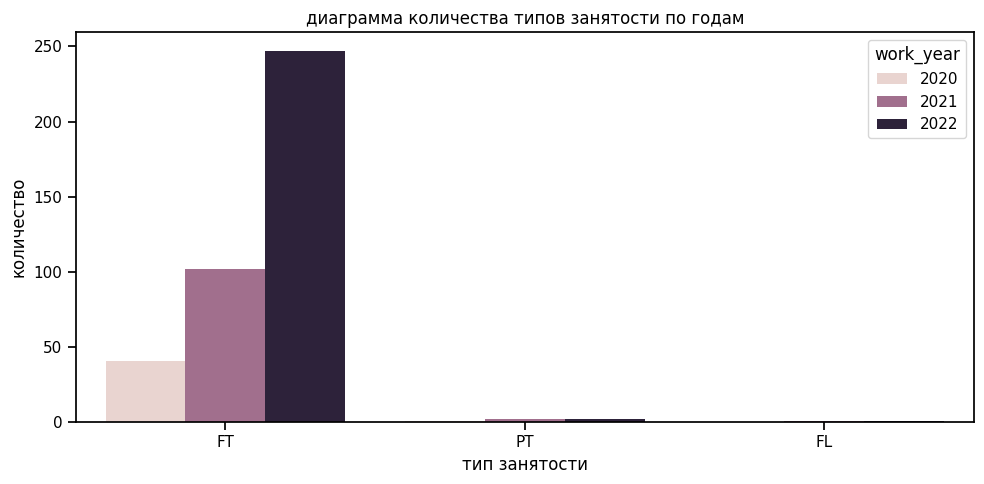

In [543]:
# подготовка агрегированной таблицы: будет считаться количество записей по каждой паре (год, тип занятости)
grp = (
    df.groupby(['work_year', 'employment_type'])
      .size()
      .reset_index(name='count')
)

# порядок категорий по оси x: будет фиксироваться порядок FT-PT-FL
order_et = ['FT', 'PT', 'FL']

plt.figure(figsize=(10, 5))
# столбчатая диаграмма: будет отображаться count по типу занятости с разбиением по годам
sb.barplot(
    data=grp,
    x='employment_type',
    y='count',
    hue='work_year',
    order=order_et
)

plt.title('диаграмма количества типов занятости по годам')
plt.xlabel('тип занятости')
plt.ylabel('количество')
plt.legend(title='work_year')
plt.tight_layout()
plt.show()

Интерпретация:
- FT - доминировал во всех годах; к 2022 году количество записей заметно выросло относительно 2020 и 2021.
- PT - присутствовал в небольшом количестве.
- FL - встречался редко во все годы.
- общий вывод - структура занятости была стабильной: преобладала полная занятость (FT), тогда как частичная (PT) и фриланс (FL) были представлены существенно меньше.

## 5.2. Задание 2 (pandas + plot)

По сводной таблице (pivot_table) была отображена средняя зарплата в usd по локациям (company_location). линия была выполнена зеленого цвета, шириной 4, маркеры - в виде *.

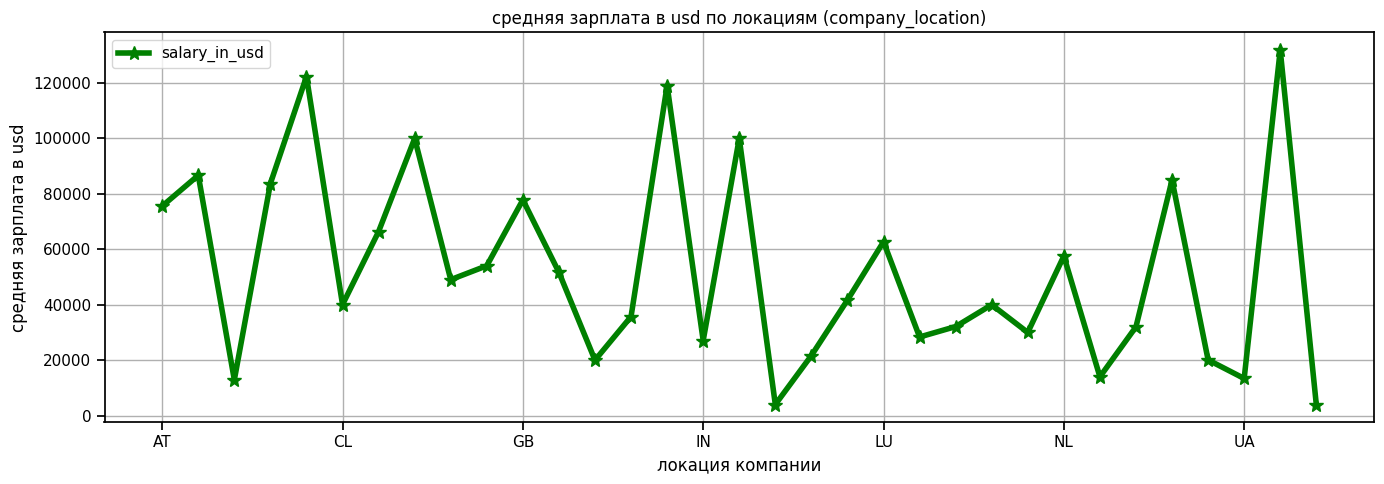

топ-5 локаций по средней зарплате в usd:
company_location      US      CH      IL      IQ      DZ
salary_in_usd     131899  122346  119059  100000  100000

ботом-5 локаций по средней зарплате в usd:
company_location    VN    IR     BR     UA     PK
salary_in_usd     4000  4000  12901  13400  14000


In [544]:
# сводная таблица: будет считаться средняя зарплата в usd по локациям
pt = (
    df.pivot_table(index='company_location', values='salary_in_usd', aggfunc='mean')
      .sort_index()  # будет упорядочивать локации по алфавиту
)

# линейный график средствами pandas
ax = pt.plot(
    kind='line',
    y='salary_in_usd',
    color='green',      # будет задаваться зеленый цвет линии
    linewidth=4,        # будет задаваться ширина линии
    marker='*',         # будут отображаться маркеры как звездочки
    markersize=10,
    figsize=(14, 5),
    grid=True,
    legend=True
)

plt.title('средняя зарплата в usd по локациям (company_location)')
plt.xlabel('локация компании')
plt.ylabel('средняя зарплата в usd')
plt.tight_layout()
plt.show()

# для удобства интерпретации: будет выводиться топ-5 и ботов-5 локаций по средней зарплате
top5 = pt.sort_values('salary_in_usd', ascending=False).head(5)
bot5 = pt.sort_values('salary_in_usd', ascending=True).head(5)
print('топ-5 локаций по средней зарплате в usd:')
print(top5.round(0).astype(int).T)
print('\nботом-5 локаций по средней зарплате в usd:')
print(bot5.round(0).astype(int).T)

Интерпретация:
- На графике были видны существенные различия средних зарплат по локациям: часть стран имела уровень заметно выше среднего, часть - ниже.
- Линия с маркерами позволяла отследить пики и провалы по конкретным локациям; лидеры и аутсайдеры были подтверждены в сводной таблице (top-5 и bottom-5).

## 5.3. Задание 3 (matplotlib)

Была построена круговая диаграмма, которая отображала процент количества записей по каждому году. это позволило оценить долю наблюдений за 2020, 2021 и 2022 годы.

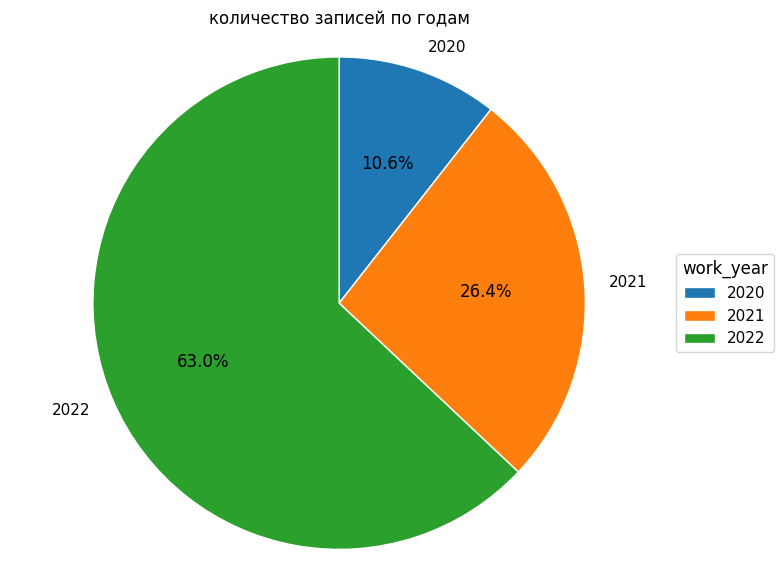

число записей по годам:
work_year
2020     42
2021    105
2022    250
Name: count, dtype: int64


In [545]:
# подготовка данных: будет считаться количество записей по годам и будет упорядочиваться по возрастанию года
year_counts = df['work_year'].value_counts().sort_index()
labels = year_counts.index.astype(str).tolist()
sizes = year_counts.values

plt.figure(figsize=(8, 6))

# будет строиться круговая диаграмма
# labels=... - будет подписывать сектора годами
# autopct="%.1f%%" - будет показывать проценты с одним знаком после запятой
# startangle=90 - будет поворачивать диаграмму, чтобы первый сектор начинался сверху
# counterclock=False - будет располагать сектора по часовой стрелке
# wedgeprops={"linewidth": 1, "edgecolor": "white"} - будет добавлять белые границы между секторами
plt.pie(
    sizes,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

plt.title("количество записей по годам")
plt.legend(title="work_year", loc="center left", bbox_to_anchor=(1, 0.5))
plt.axis("equal")  # будет делать круг пропорциональным (не овал)
plt.tight_layout()
plt.show()

# при необходимости будет выводиться таблица с абсолютными значениями:
print("число записей по годам:")
print(year_counts)


Интерпретация:
- 2022 год имел наибольшую долю записей (около 63%).
- 2021 год занимал примерно четверть выборки (около 26%).
- 2020 год был представлен минимально (около 11%).
Таким образом, основная часть наблюдений приходилась на 2022 год, что объясняло слабые линейные связи с work_year в предыдущих разделах (узкий и несбалансированный временной диапазон).

# 6. Hexagonal binning plot

Был построен график типа "hexagonal binning plot" для пары признаков "общий опыт" и "зарплата в usd". такой график агрегировал точки в шестиугольные ячейки и отражал плотность наблюдений по интенсивности цвета.

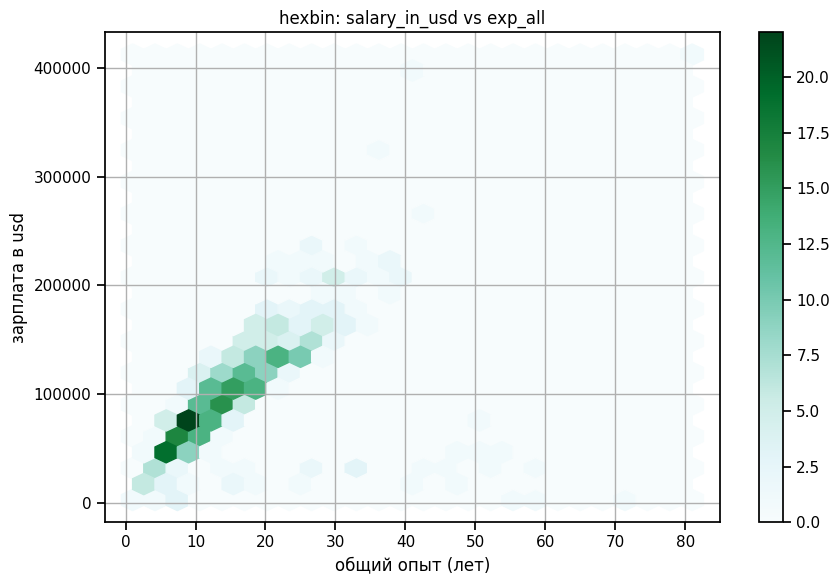

In [546]:
# hexbin: exp_all - salary_in_usd

# pandas plot(kind="hexbin") - будет строить "шестиугольную" карту плотности
# x, y - будут задавать оси признаков
# gridsize - будет задавать крупность сетки (большее значение - более мелкие ячейки)
# sharex=False, grid=True - будут управлять осями и сеткой
ax = df.plot(
    kind="hexbin",
    x="exp_all",
    y="salary_in_usd",
    gridsize=25,
    figsize=(9, 6),
    sharex=False,
    grid=True
)

plt.title("hexbin: salary_in_usd vs exp_all")
plt.xlabel("общий опыт (лет)")
plt.ylabel("зарплата в usd")
plt.tight_layout()
plt.show()

Выводы:
- Максимальная плотность наблюдений приходилась на зону exp_all 10-25 лет и salary_in_usd около 80k-160k.
- При exp_all ниже 10 лет наблюдений было меньше и зарплаты концентрировались в нижней части шкалы.
- Правее 30 лет опыта плотность снижалась, но встречались отдельные ячейки с повышенными зарплатами, что соответствовало меньшему числу специалистов с большим стажем.
- Распределение подтверждало выводы из scatter-графиков и гистограмм: зарплата в usd росла с опытом до 20-30 лет, при этом сохранялся широкий диапазон значений.

# 7. Boxplot

Был выполнен график boxplot для столбца "salary_in_usd". Диаграмма размаха показывала медиану, квартильный ящик (Q1–Q3), "усы" до 1.5*IQR и выбросы как отдельные точки.

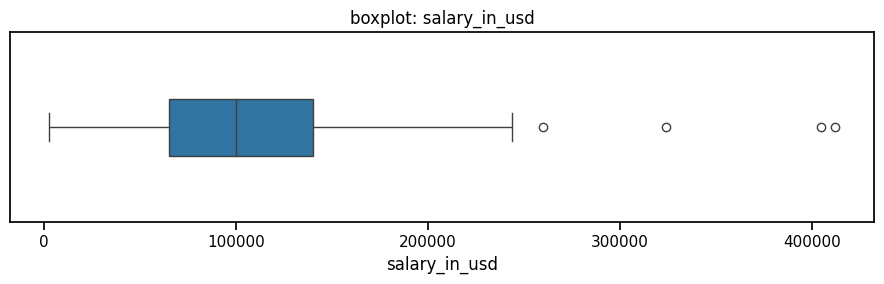

In [547]:
# boxplot по зарплате в usd
plt.figure(figsize=(9, 3))

# будет строиться boxplot по salary_in_usd
# orient='h' - будет поворачивать график горизонтально
# width=0.3 - будет задаваться ширина ящика
sb.boxplot(x='salary_in_usd', data=df, orient='h', width=0.3)

plt.title('boxplot: salary_in_usd')
plt.xlabel('salary_in_usd')
plt.yticks([])  # будет убирать подписи по оси y, так как одна категория
plt.tight_layout()
plt.show()

По созданному графику были подведены следующие итоги:
- Медиана находилась около 100k usd, что совпадало с ранее полученной сводной статистикой.
- Межквартильный размах (Q1–Q3) располагался примерно в диапазоне 65k–140k usd.
- Усы тянулись вправо, и наблюдалось много выбросов выше верхнего уса — распределение было правосторонним с длинным хвостом.
- Нижние выбросы встречались редко; основная вариативность приходилась на верхнюю часть распределения.

# 8. Добавление категорий и boxplot по категориям

По столбцу "salary_in_usd" была автоматически создана категориальная переменная "salary_level" с помощью pd.qcut на 3 квантильные группы: "низкая", "средняя", "высокая". Затем был построен boxplot зарплаты в usd по каждой категории.

распределение по категориям salary_level:
salary_level
низкая     135
средняя    129
высокая    133
Name: count, dtype: int64


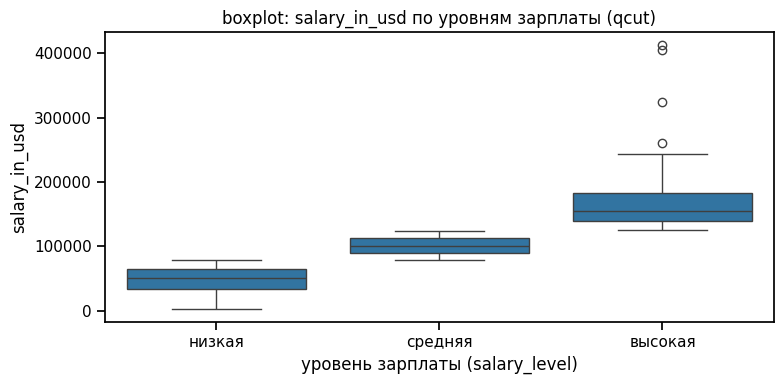

In [548]:
# автоматическая категоризация зарплаты в usd на 3 квантильные группы с помощью qcut
# pd.qcut(..., q=3) - будет делить значения на 3 равномерные группы
# labels - будут задавать имена категорий в порядке возрастания зарплаты
labels = ["низкая", "средняя", "высокая"]
df["salary_level"] = pd.qcut(
    df["salary_in_usd"],
    q=3,
    labels=labels,
)

# проверим баланс категорий
print("распределение по категориям salary_level:")
print(df["salary_level"].value_counts().reindex(labels))

# boxplot зарплаты по уровням, порядок оси x будет зафиксирован
plt.figure(figsize=(8, 4))
sb.boxplot(data=df, x="salary_level", y="salary_in_usd", order=labels)
plt.title("boxplot: salary_in_usd по уровням зарплаты (qcut)")
plt.xlabel("уровень зарплаты (salary_level)")
plt.ylabel("salary_in_usd")
plt.tight_layout()
plt.show()

По созданному графику были подведены следующие итоги:
- Медианы последовательно возрастали от "низкой" к "высокой" группе.
- Разброс значений был минимальным в "низкой" группе и максимальным в "высокой", где наблюдалось больше выбросов.
- Квантильная разбивка обеспечила сопоставимые по размеру группы, что сделало сравнение распределений наглядным.

# 9. Дополнительные boxplot по другим категориям

В разделе были построены два графика boxplot с использованием разных библиотек:
- seaborn: зарплата в usd по должностям (топ-3, чтобы повысить читаемость),
- pandas (matplotlib): зарплата в usd по типу занятости.

## 9.1. Boxplot зарплаты по должностям (seaborn)

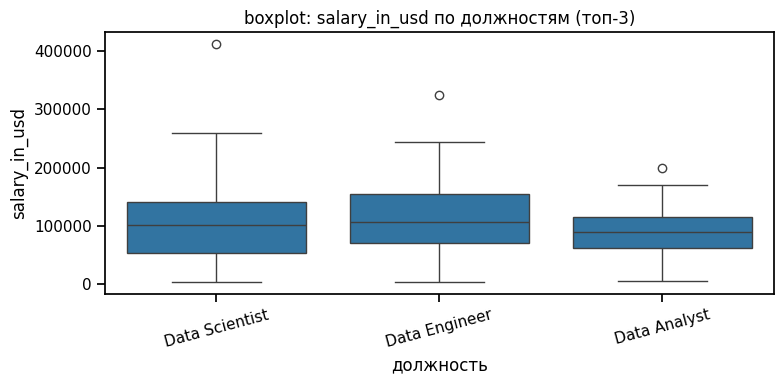

In [549]:
# выбор топ-3 должностей по частоте
# value_counts().nlargest(3) - вернет три самые частые должности
top_titles = df['job_title'].value_counts().nlargest(3).index
df_top = df[df['job_title'].isin(top_titles)].copy()

plt.figure(figsize=(8, 4))
# boxplot по зарплате в usd для выбранных должностей
# order=top_titles - будет фиксировать порядок категорий
sb.boxplot(data=df_top, x='job_title', y='salary_in_usd', order=top_titles)

plt.title('boxplot: salary_in_usd по должностям (топ-3)')
plt.xlabel('должность')
plt.ylabel('salary_in_usd')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Наблюдения:
- Медиана salary_in_usd: Data Engineer > Data Scientist > Data Analyst.
- Межквартильный размах: у Data Engineer самый широкий и смещен выше; у Data Scientist немного ниже; у Data Analyst уже и расположен ниже.
- Верхние усы и выбросы: у Data Scientist отмечен самый высокий выброс (~410k), у Data Engineer ~320k, у Data Analyst ~200k; у всех распределение правоскорое.
- Диапазоны распределений частично перекрывались, но порядок уровней по медиане и IQR сохранялся: инженеры выше, аналитики ниже.
- Низкие значения (<50k) встречались у всех ролей, чаще у Data Analyst.

## 9.2. Boxplot зарплаты по типу занятости (pandas + matplotlib)

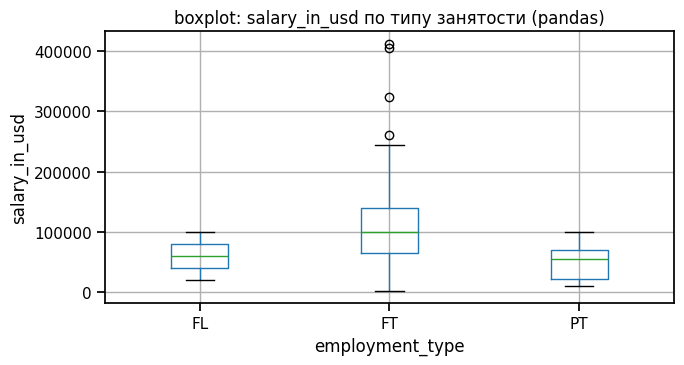

In [550]:
# boxplot средствами pandas: зарплата в usd по типу занятости
ax = df.boxplot(column='salary_in_usd', by='employment_type', grid=True, figsize=(7, 4))

plt.title('boxplot: salary_in_usd по типу занятости (pandas)')
plt.suptitle('')  # будет убирать автоматический надзаголовок pandas
plt.xlabel('employment_type')
plt.ylabel('salary_in_usd')
plt.tight_layout()
plt.show()

Наблюдения:
- FT имел более высокую медиану и больший разброс, чем PT и FL.
- PT и FL характеризовались более низкими уровнями и компактными распределениями.
- Различия соответствовали структуре выборки и долям типов занятости.

Итог по двум заданиям:
- По обеим категориям были отмечены различия уровней и разброса зарплат; наиболее высокие медианы приходились на технические роли и полную занятость.
- Использование двух библиотек (seaborn и pandas/matplotlib) подтвердило устойчивость наблюдений.

# 10. Выводы

В ходе лабораторной работы был выполнен полный цикл исследовательского анализа данных по набору salary2.csv. была проведена предобработка: удалены пропуска, исправлены типы столбцов, устранены неявные дубликаты, исправлены противоречивые связки, удалены отрицательные значения. После очистки осталось 397 записей.

По матрице диаграмм рассеяния и точечным графикам по категориям была изучена структура связей. Зарплата в usd имела нарастающую тенденцию с общим опытом до 20-30 лет, после чего разброс значений увеличивался. при сравнении ролей в фокусной диаграмме для топ-3 должностей было установлено, что при сопоставимом опыте уровни зарплат различались. Различия на малых сроках опыта 0-10 лет были несущественными и распределения ролей пересекались.

Гистограммы показали правую асимметрию по зарплатам, особенно для "salary", где присутствовали редкие экстремальные значения в миллионах. Распределение "salary_in_usd" было более стабильным, с медианой около 100k и основной массой в диапазоне 60k-140k. По "exp_all" наблюдалась концентрация 10-25 лет и длинный правый хвост, "exp" концентрировался в пределах 3-6 лет. По годам основная доля записей приходилась на 2022, что ограничивало возможность выявления временных трендов.

По матрице корреляций и тепловой карте была зафиксирована умеренная связь между "salary_in_usd" и "exp_all" r=0.50, слабая положительная связь между "work_year" и "salary_in_usd" r=0.33, слабая-умеренная между "salary" и "exp_all" r=0.32. связи "exp" с остальными признаками были близки к нулю. Ковариации имели те же знаки, однако их величины зависели от масштаба, поэтому для сравнения силы связей использовались коэффициенты корреляции. Выводом стало то, что для сравнения зарплат корректнее использовать "salary_in_usd", так как "salary" в локальных валютах искажалась курсами и выбросами.

В индивидуальных заданиях была подтверждена доминирующая доля полной занятости FT во всех годах, значимые межстрановые различия средней зарплаты в usd и преобладание записей 2022 года. Совокупно это объясняло слабые связи с "work_year".

В заключение было показано, что структура данных характеризовалась правой асимметрией по зарплатам, умеренной линейной зависимостью зарплаты в usd от общего опыта и заметными различиями по категориям ролей и типов занятости.